In [4]:
from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [5]:
load_dotenv()

True

In [ ]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [7]:
class LLMState(TypedDict):
    question:str
    answer:str

In [33]:
def llm_qa(State : LLMState) ->LLMState:
    que=State['question']
    prompt= f"answer the following question in few words{que}"
    ans=llm.invoke(prompt)
    State['answer']=ans
    return State

In [34]:
graph= StateGraph(LLMState)

graph.add_node("llm qa",llm_qa)

graph.add_edge(START,"llm qa")
graph.add_edge("llm qa",END)
workflow=graph.compile()


In [35]:
que={"question":"who is salman khan"}

In [36]:
ans=workflow.invoke(que)

In [37]:
print(ans["answer"].content)


Indian film actor.


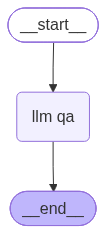

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())